# NB04: Model Reconciliation

Can new AI-generated annotations help fill gaps in the FBA metabolic model?

The FBA model predicted essentiality with ~74% concordance but failed on aromatic catabolism.
We examine:
1. FBA-discordant genes: do new annotations explain prediction failures?
2. Reaction coverage: do new annotations suggest missing reactions?
3. Quinate-specific genes without FBA reactions: can the agent explain them?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
import re

PROJECT_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
if 'adp1_annotation_reassessment' not in PROJECT_DIR:
    PROJECT_DIR = 'projects/adp1_annotation_reassessment'
REPO_ROOT = os.path.dirname(os.path.dirname(PROJECT_DIR)) if 'projects' in PROJECT_DIR else os.path.dirname(PROJECT_DIR)
if not os.path.exists(os.path.join(REPO_ROOT, 'projects')):
    REPO_ROOT = '.'

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

master = pd.read_csv(os.path.join(PROJECT_DIR, 'data/master_annotation_table.csv'))
print(f'Master table: {len(master)} genes')

Master table: 5852 genes


## Load FBA/Essentiality Data

**Cross-project dependencies:** This notebook loads FBA concordance data from a sibling project:
- `projects/adp1_triple_essentiality/data/triple_gene_table.csv` — 478 genes with FBA concordance classes
- `projects/adp1_deletion_phenotypes/data/condition_specific_genes.csv` — condition-specific growth phenotypes (used in Part 3)

In [2]:
# Triple essentiality table (478 genes with FBA concordance classes)
triple = pd.read_csv(os.path.join(REPO_ROOT, 'projects/adp1_triple_essentiality/data/triple_gene_table.csv'))
print(f'Triple essentiality genes: {len(triple)}')
print(f'Concordance classes:')
print(triple['concordance_class'].value_counts())

# Gene-reaction data from the FBA model
conn = sqlite3.connect(os.path.join(PROJECT_DIR, 'user_data/berdl_tables.db'))
gene_rxn = pd.read_sql('SELECT * FROM gene_reaction_data', conn)
conn.close()
print(f'\nGene-reaction mappings: {len(gene_rxn)} rows')
print(f'Columns: {list(gene_rxn.columns)}')

Triple essentiality genes: 478
Concordance classes:
concordance_class
FBA-variable + growth-defect     150
FBA-blocked + growth-defect      136
FBA-blocked + growth-normal       60
FBA-essential + growth-defect     57
FBA-variable + growth-normal      54
FBA-essential + growth-normal     21
Name: count, dtype: int64

Gene-reaction mappings: 12311 rows
Columns: ['genome_id', 'gene_id', 'reaction', 'rich_media_flux', 'rich_media_class', 'minimal_media_flux', 'minimal_media_class']


## Part 1: FBA-Discordant Genes

Focus on genes where FBA prediction does NOT match experimental outcome.

In [3]:
# Merge triple essentiality with master table to get agent annotations
triple_merged = triple.merge(
    master[['feature_id', 'agent_annotation', 'agent_class', 'rast_class', 'bakta_class']],
    on='feature_id', how='left'
)
print(f'Triple genes with agent annotation: {triple_merged["agent_annotation"].notna().sum()}/{len(triple_merged)}')

# Define discordant classes
# FBA-blocked + growth-normal: FBA says essential, experiment says dispensable
# FBA-variable + growth-defect: FBA says dispensable, experiment says important
# FBA-essential + growth-normal: FBA says essential, experiment says dispensable
discordant_classes = ['FBA-blocked + growth-normal', 'FBA-essential + growth-normal']
concordant_classes = ['FBA-blocked + growth-defect', 'FBA-essential + growth-defect',
                      'FBA-variable + growth-normal']
# FBA-variable + growth-defect is interesting: FBA has the reaction but doesn't predict essentiality
fba_miss_classes = ['FBA-variable + growth-defect']

discordant = triple_merged[triple_merged['concordance_class'].isin(discordant_classes)]
fba_miss = triple_merged[triple_merged['concordance_class'].isin(fba_miss_classes)]
concordant = triple_merged[triple_merged['concordance_class'].isin(concordant_classes)]

print(f'\nFBA-discordant (FBA essential, growth normal): {len(discordant)}')
print(f'FBA misses (FBA variable, growth defect): {len(fba_miss)}')
print(f'FBA concordant: {len(concordant)}')

Triple genes with agent annotation: 478/478

FBA-discordant (FBA essential, growth normal): 81
FBA misses (FBA variable, growth defect): 150
FBA concordant: 247


In [4]:
# Annotation coverage in discordant vs concordant genes
print('Annotation status in FBA-discordant genes:')
for cls_name, df in [('Discordant', discordant), ('FBA-miss', fba_miss), ('Concordant', concordant)]:
    n = len(df)
    rast_spec = (df['rast_class'] == 'specific').sum()
    bakta_spec = (df['bakta_class'] == 'specific').sum()
    agent_spec = (df['agent_class'] == 'specific').sum()
    rast_hypo = (df['rast_class'] == 'hypothetical').sum()
    agent_hypo = (df['agent_class'] == 'hypothetical').sum()
    print(f'\n{cls_name} ({n} genes):')
    print(f'  RAST specific: {rast_spec} ({rast_spec/n*100:.0f}%), hypothetical: {rast_hypo}')
    print(f'  Bakta specific: {bakta_spec} ({bakta_spec/n*100:.0f}%)')
    print(f'  Agent specific: {agent_spec} ({agent_spec/n*100:.0f}%), hypothetical: {agent_hypo}')

Annotation status in FBA-discordant genes:

Discordant (81 genes):
  RAST specific: 81 (100%), hypothetical: 0
  Bakta specific: 81 (100%)
  Agent specific: 81 (100%), hypothetical: 0

FBA-miss (150 genes):
  RAST specific: 150 (100%), hypothetical: 0
  Bakta specific: 150 (100%)
  Agent specific: 149 (99%), hypothetical: 1

Concordant (247 genes):
  RAST specific: 247 (100%), hypothetical: 0
  Bakta specific: 247 (100%)
  Agent specific: 247 (100%), hypothetical: 0


In [5]:
# FBA-miss genes (variable flux but growth defect): does agent annotation suggest metabolic function?
METABOLIC_KEYWORDS = ['synthase', 'transferase', 'kinase', 'dehydrogenase', 'reductase',
                      'oxidase', 'lyase', 'ligase', 'isomerase', 'mutase', 'phosphatase',
                      'esterase', 'hydrolase', 'epimerase', 'racemase', 'transaminase',
                      'coa', 'nad', 'fad', 'atp', 'metabolism', 'biosynthesis',
                      'catabolism', 'pathway', 'transport']

def has_metabolic_annotation(ann):
    if pd.isna(ann): return False
    ann_lower = str(ann).lower()
    return any(kw in ann_lower for kw in METABOLIC_KEYWORDS)

for cls_name, df in [('FBA-miss', fba_miss), ('Discordant', discordant)]:
    print(f'\n{cls_name} genes with metabolic annotation:')
    for source, col in [('RAST', 'rast_function'), ('Bakta', 'bakta_function'), ('Agent', 'agent_annotation')]:
        n_metab = df[col].apply(has_metabolic_annotation).sum()
        print(f'  {source}: {n_metab}/{len(df)} ({n_metab/len(df)*100:.1f}%)')


FBA-miss genes with metabolic annotation:
  RAST: 116/150 (77.3%)
  Bakta: 115/150 (76.7%)
  Agent: 128/150 (85.3%)

Discordant genes with metabolic annotation:
  RAST: 57/81 (70.4%)
  Bakta: 59/81 (72.8%)
  Agent: 70/81 (86.4%)


## Part 2: Reaction Coverage

For genes with agent annotations, how many have reaction mappings in the model? Does the agent suggest missing reactions?

In [6]:
# Check gene_reaction_data structure
# Note: the SQLite database contains multi-genome FBA data from the upstream
# acinetobacter_adp1_explorer project. Of 12,311 gene-reaction rows, only 866
# map to ADP1 features in our master table.
print(f'Gene-reaction data: {len(gene_rxn)} rows (multi-genome, from upstream project)')
print(gene_rxn.head(3))

# How many genes have reaction mappings?
if 'feature_id' in gene_rxn.columns:
    genes_with_rxn = set(gene_rxn['feature_id'])
elif 'gene_id' in gene_rxn.columns:
    genes_with_rxn = set(gene_rxn['gene_id'])
else:
    print('Available columns:', list(gene_rxn.columns))
    genes_with_rxn = set()

print(f'\nGenes with reaction mappings (all genomes): {len(genes_with_rxn)}')

# How many of these are in the master table?
master_features = set(master['feature_id'])
rxn_in_master = genes_with_rxn & master_features
print(f'Reaction-mapped genes in ADP1 master table: {len(rxn_in_master)}')

Gene-reaction data: 12311 rows (multi-genome, from upstream project)
            genome_id                gene_id                    reaction  \
0  RS_GCF_010577925.1   NZ_MPVY01000001.1_41  rxn02200;rxn02201;rxn02503   
1  RS_GCF_010577925.1  NZ_MPVY01000003.1_490  rxn02200;rxn02201;rxn02503   
2  RS_GCF_010577925.1  NZ_MPVY01000010.1_199           rxn02200;rxn02201   

   rich_media_flux rich_media_class  minimal_media_flux minimal_media_class  
0         0.008108         variable            0.000686            variable  
1         0.008108         variable            0.000686            variable  
2         0.008108         variable            0.000686            variable  

Genes with reaction mappings (all genomes): 12311
Reaction-mapped genes in ADP1 master table: 866


In [7]:
# Genes WITHOUT reaction mappings but with agent metabolic annotations
# These could be candidates for model expansion
no_rxn_genes = master[~master['feature_id'].isin(genes_with_rxn)].copy()
no_rxn_with_agent = no_rxn_genes[no_rxn_genes['agent_class'] == 'specific'].copy()

# Check which have metabolic-sounding agent annotations
no_rxn_with_agent['agent_metabolic'] = no_rxn_with_agent['agent_annotation'].apply(has_metabolic_annotation)
no_rxn_with_agent['rast_metabolic'] = no_rxn_with_agent['rast_function'].apply(has_metabolic_annotation)

agent_new_metabolic = no_rxn_with_agent[
    no_rxn_with_agent['agent_metabolic'] & ~no_rxn_with_agent['rast_metabolic']
]
print(f'Genes without reactions: {len(no_rxn_genes)}')
print(f'  With agent specific annotation: {len(no_rxn_with_agent)}')
print(f'  With agent metabolic annotation: {no_rxn_with_agent["agent_metabolic"].sum()}')
print(f'  Agent metabolic but RAST not: {len(agent_new_metabolic)} (model expansion candidates)')

# Show top examples
print(f'\nTop model expansion candidates (agent provides metabolic annotation, no current reaction):')
for _, row in agent_new_metabolic.head(10).iterrows():
    print(f'  {row["feature_id"]} ({row["old_locus_tag"]})')
    print(f'    RAST:  {row["rast_function"]}')
    agent_short = str(row['agent_annotation'])[:130]
    print(f'    Agent: {agent_short}' + ('...' if len(str(row['agent_annotation'])) > 130 else ''))
    print()

Genes without reactions: 4986
  With agent specific annotation: 2121
  With agent metabolic annotation: 1349
  Agent metabolic but RAST not: 696 (model expansion candidates)

Top model expansion candidates (agent provides metabolic annotation, no current reaction):
  ACIAD_RS16630 (nan)
    RAST:  Membrane fusion component of MSF-type tripartite multidrug efflux system
    Agent: Periplasmic membrane fusion/adaptor protein (AcrA/MdtA-like) that partners with inner-membrane multidrug transporters and an outer...

  ACIAD_RS16625 (ACIAD3678)
    RAST:  Inner-membrane proton/drug antiporter (MSF type) of tripartite multidrug efflux system
    Agent: Predicted EmrB-like major facilitator superfamily (MFS) transporter, likely functioning as a drug/multidrug efflux pump.

  ACIAD_RS16615 (ACIAD3676)
    RAST:  Homolog of plant auxin-responsive GH3-like protein
    Agent: Glycoside hydrolase family 3 (GH3) enzyme, likely a beta-N-acetylglucosaminidase/beta-glucosidase that hydrolyzes glycosid

In [8]:
# Tighter model expansion candidates: restrict to annotations with EC numbers
# or explicit enzyme class terms, excluding transport/chaperone/stress categories.

ENZYME_KEYWORDS = ['synthase', 'kinase', 'dehydrogenase', 'reductase', 'oxidase',
                   'lyase', 'ligase', 'isomerase', 'mutase', 'phosphatase', 'esterase',
                   'hydrolase', 'epimerase', 'racemase', 'transaminase', 'carboxylase',
                   'desaturase', 'oxygenase', 'aldolase', 'decarboxylase']
EXCLUDE_KEYWORDS = ['transport', 'chaperone', 'stress', 'efflux', 'permease', 'porin',
                    'regulator', 'transcriptional', 'structural', 'ribosom']
EC_PATTERN = re.compile(r'EC\s*[\d]+\.[\d]+\.[\d]+\.[\d]+', re.IGNORECASE)

def is_strict_enzyme(ann):
    if pd.isna(ann): return False
    ann_lower = str(ann).lower()
    has_enzyme = EC_PATTERN.search(str(ann)) or any(kw in ann_lower for kw in ENZYME_KEYWORDS)
    is_excluded = any(kw in ann_lower for kw in EXCLUDE_KEYWORDS)
    return has_enzyme and not is_excluded

strict_candidates = agent_new_metabolic[agent_new_metabolic['agent_annotation'].apply(is_strict_enzyme)]
print(f'Model expansion candidates:')
print(f'  Broad filter (metabolic keywords):   {len(agent_new_metabolic)}')
print(f'  Strict filter (enzyme class/EC only): {len(strict_candidates)}')
print(f'\nStrict candidates include genes with enzyme class terms (synthase, kinase, etc.)')
print(f'or EC numbers, excluding transport, chaperone, stress, and regulatory proteins.')

# Show examples of strict candidates
print(f'\nTop strict model expansion candidates:')
for _, row in strict_candidates.head(8).iterrows():
    agent_short = str(row['agent_annotation'])[:120]
    suffix = '...' if len(str(row['agent_annotation'])) > 120 else ''
    print(f'  {row["feature_id"]}: {agent_short}{suffix}')

Model expansion candidates:
  Broad filter (metabolic keywords):   696
  Strict filter (enzyme class/EC only): 175

Strict candidates include genes with enzyme class terms (synthase, kinase, etc.)
or EC numbers, excluding transport, chaperone, stress, and regulatory proteins.

Top strict model expansion candidates:
  ACIAD_RS16600: Predicted thiol–disulfide interchange protein of the DsbC/DsbG family (thioredoxin-like disulfide bond isomerase), likel...
  ACIAD_RS16515: Predicted metallo-β-lactamase–superfamily metal-dependent hydrolase (ribonuclease Z/glyoxalase II-like), likely function...
  ACIAD_RS16345: Short-chain acyl-CoA dehydrogenase involved in branched-chain amino acid (especially isoleucine) catabolism, likely oxid...
  ACIAD_RS16195: Putative extradiol ring-cleavage dioxygenase (Glyoxalase/Bleomycin resistance protein/dihydroxybiphenyl dioxygenase supe...
  ACIAD_RS16145: Glutathione-dependent maleylacetoacetate isomerase (HmgB)-like enzyme involved in homogentisate pathwa

## Part 3: Quinate-Specific Genes Without FBA Reactions

In [9]:
# Load condition-specific genes and find quinate-specific ones
cond_specific = pd.read_csv(os.path.join(REPO_ROOT, 'projects/adp1_deletion_phenotypes/data/condition_specific_genes.csv'))
quinate_specific = cond_specific[
    (cond_specific['most_specific_condition'] == 'quinate') &
    (cond_specific['max_specificity'] > 1.5)
].copy()
print(f'Quinate-specific genes: {len(quinate_specific)}')

# Merge with master to get agent annotations
quinate_merged = quinate_specific.merge(
    master[['feature_id', 'rast_function', 'bakta_function', 'agent_annotation',
            'rast_class', 'bakta_class', 'agent_class', 'reactions', 'minimal_media_class']],
    on='feature_id', how='left', suffixes=('_qs', '')
)

# How many have FBA reactions?
has_rxn = quinate_merged['reactions'].notna() & (quinate_merged['reactions'] != '')
no_rxn = ~has_rxn
print(f'  With FBA reaction: {has_rxn.sum()}')
print(f'  Without FBA reaction: {no_rxn.sum()}')

# For those without reactions, what does the agent say?
quinate_no_rxn = quinate_merged[no_rxn]
print(f'\nQuinate-specific genes WITHOUT FBA reactions:')
print(f'  RAST specific: {(quinate_no_rxn["rast_class"] == "specific").sum()}')
print(f'  Bakta specific: {(quinate_no_rxn["bakta_class"] == "specific").sum()}')
print(f'  Agent specific: {(quinate_no_rxn["agent_class"] == "specific").sum()}')
print(f'  RAST hypothetical: {(quinate_no_rxn["rast_class"] == "hypothetical").sum()}')
print(f'  Agent hypothetical: {(quinate_no_rxn["agent_class"] == "hypothetical").sum()}')

Quinate-specific genes: 27
  With FBA reaction: 16
  Without FBA reaction: 11

Quinate-specific genes WITHOUT FBA reactions:
  RAST specific: 10
  Bakta specific: 10
  Agent specific: 11
  RAST hypothetical: 1
  Agent hypothetical: 0


In [10]:
# Show quinate-specific genes without reactions where agent provides specific annotation
quinate_agent_specific = quinate_no_rxn[quinate_no_rxn['agent_class'] == 'specific']
print(f'Quinate-specific genes without reactions, agent provides specific annotation ({len(quinate_agent_specific)}):')
print('=' * 120)
for _, row in quinate_agent_specific.iterrows():
    print(f'  {row["feature_id"]} ({row.get("old_locus_tag", "?")})')
    print(f'    RAST:  {row["rast_function"]}')
    print(f'    Bakta: {row["bakta_function"]}')
    agent_short = str(row['agent_annotation'])[:140]
    print(f'    Agent: {agent_short}' + ('...' if len(str(row['agent_annotation'])) > 140 else ''))
    print(f'    Specificity: {row["max_specificity"]:.2f}, Direction: {row["specificity_direction"]}')
    print()

Quinate-specific genes without reactions, agent provides specific annotation (11):
  ACIAD_RS14175 (ACIAD3137)
    RAST:  UPF0234 protein Yitk
    Bakta: YajQ family cyclic di-GMP-binding protein
    Agent: YajQ/UPF0234 family nucleotide-binding (putative c-di-GMP–binding) regulatory protein associated with branched-chain amino acid (leucine/val...
    Specificity: 6.14, Direction: defect

  ACIAD_RS12425 (ACIAD2741)
    RAST:  Phage capsid and scaffold
    Bakta: Phage capsid protein
    Agent: Phage/contractile injection system tail sheath–like structural protein (T6SS/eCIS-related), whose loss causes condition-dependent fitness ef...
    Specificity: 6.05, Direction: defect

  ACIAD_RS11380 (ACIAD2506)
    RAST:  Coenzyme PQQ synthesis protein D
    Bakta: pyrroloquinoline quinone biosynthesis peptide chaperone PqqD
    Agent: Coenzyme PQQ biosynthesis protein PqqD, a small accessory factor required for maturation of PQQ (redox cofactor for PQQ-dependent dehydrogen...
    Specificit

## Summary Figure: FBA Concordance by Annotation Source

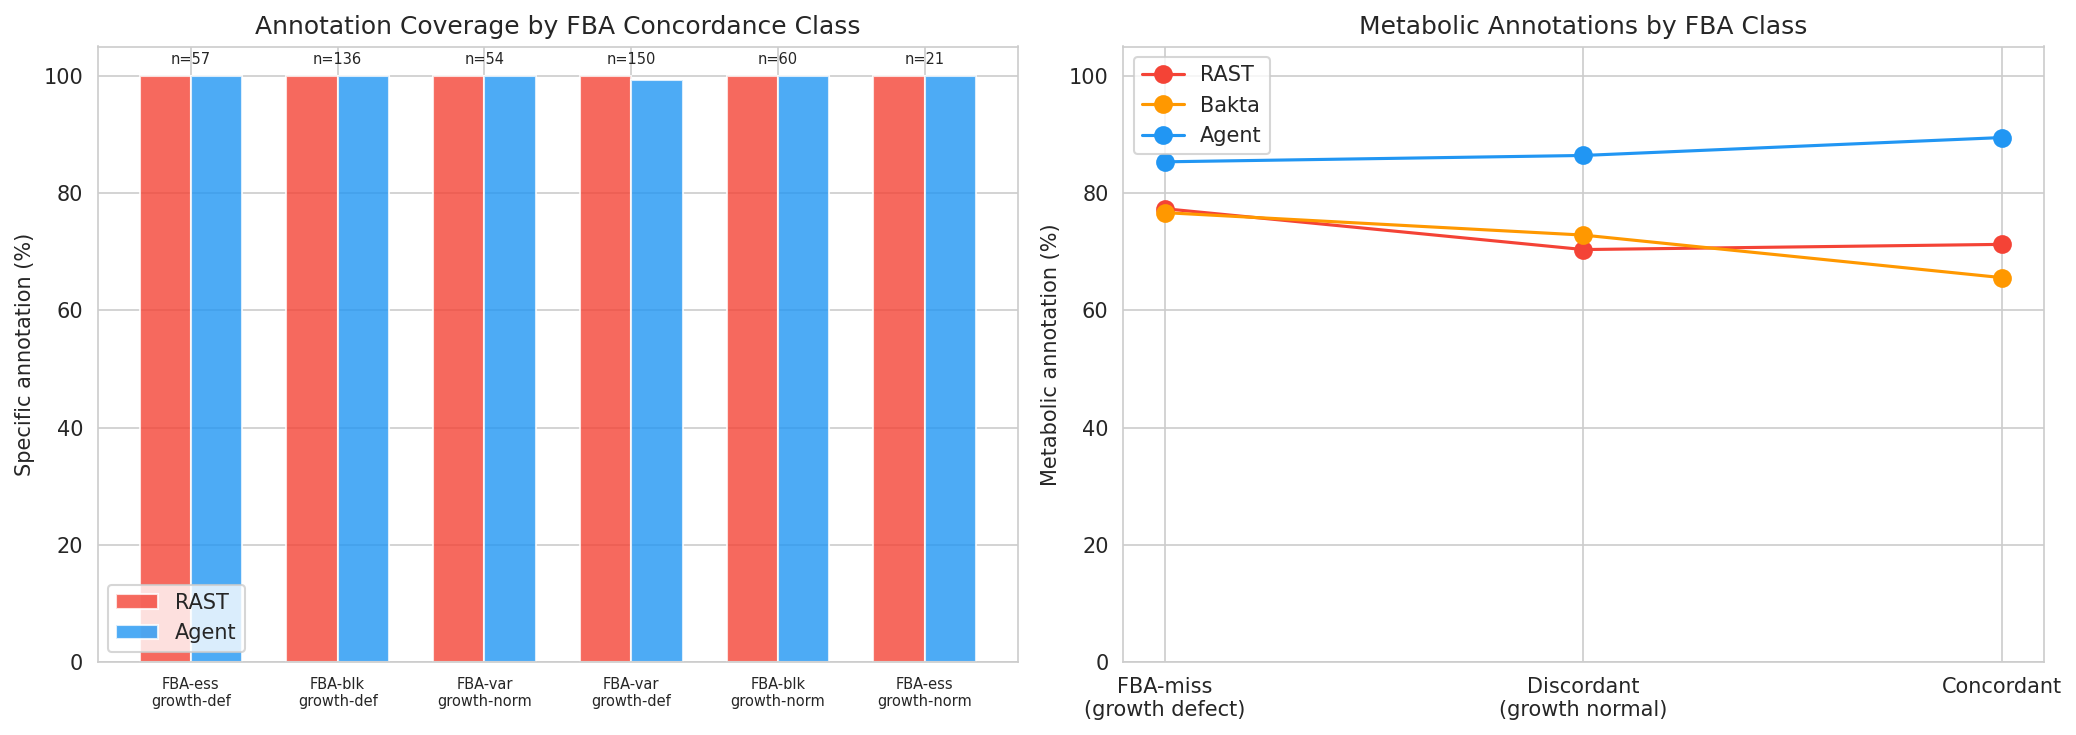

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Annotation coverage across concordance classes
ax = axes[0]
class_order = ['FBA-essential + growth-defect', 'FBA-blocked + growth-defect',
               'FBA-variable + growth-normal', 'FBA-variable + growth-defect',
               'FBA-blocked + growth-normal', 'FBA-essential + growth-normal']
class_labels = ['FBA-ess\ngrowth-def', 'FBA-blk\ngrowth-def',
                'FBA-var\ngrowth-norm', 'FBA-var\ngrowth-def',
                'FBA-blk\ngrowth-norm', 'FBA-ess\ngrowth-norm']

agent_specific_rates = []
rast_specific_rates = []
counts = []
for cls in class_order:
    subset = triple_merged[triple_merged['concordance_class'] == cls]
    n = len(subset)
    counts.append(n)
    rast_specific_rates.append((subset['rast_class'] == 'specific').sum() / max(n, 1) * 100)
    agent_specific_rates.append((subset['agent_class'] == 'specific').sum() / max(n, 1) * 100)

x = np.arange(len(class_order))
width = 0.35
ax.bar(x - width/2, rast_specific_rates, width, label='RAST', color='#F44336', alpha=0.8)
ax.bar(x + width/2, agent_specific_rates, width, label='Agent', color='#2196F3', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(class_labels, fontsize=7)
ax.set_ylabel('Specific annotation (%)')
ax.set_title('Annotation Coverage by FBA Concordance Class')
ax.legend()
# Add counts
for i, c in enumerate(counts):
    ax.text(i, max(rast_specific_rates[i], agent_specific_rates[i]) + 2, f'n={c}', ha='center', fontsize=7)

# Panel 2: Metabolic annotation in FBA-miss genes
ax = axes[1]
categories = ['FBA-miss\n(growth defect)', 'Discordant\n(growth normal)', 'Concordant']
for source, col, color in [('RAST', 'rast_function', '#F44336'), ('Bakta', 'bakta_function', '#FF9800'), ('Agent', 'agent_annotation', '#2196F3')]:
    rates = []
    for df in [fba_miss, discordant, concordant]:
        n_met = df[col].apply(has_metabolic_annotation).sum()
        rates.append(n_met / len(df) * 100)
    ax.plot(categories, rates, 'o-', label=source, color=color, markersize=8)

ax.set_ylabel('Metabolic annotation (%)')
ax.set_title('Metabolic Annotations by FBA Class')
ax.legend()
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'figures/model_reconciliation.png'), dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Summary statistics
print('=== Model Reconciliation Summary ===')
print(f'\nFBA-discordant genes (FBA-essential, growth-normal): {len(discordant)}')
print(f'  Agent resolves {(discordant["agent_class"] == "specific").sum() - (discordant["rast_class"] == "specific").sum()} more genes than RAST')
print(f'\nFBA-miss genes (FBA-variable, growth-defect): {len(fba_miss)}')
print(f'  Agent provides metabolic annotation for {fba_miss["agent_annotation"].apply(has_metabolic_annotation).sum()} genes')
print(f'\nModel expansion candidates (agent metabolic, no current reaction): {len(agent_new_metabolic)}')
print(f'\nQuinate-specific genes without FBA reactions: {len(quinate_no_rxn)}')
print(f'  Agent provides specific annotation for {(quinate_no_rxn["agent_class"] == "specific").sum()} of these')

=== Model Reconciliation Summary ===

FBA-discordant genes (FBA-essential, growth-normal): 81
  Agent resolves 0 more genes than RAST

FBA-miss genes (FBA-variable, growth-defect): 150
  Agent provides metabolic annotation for 128 genes

Model expansion candidates (agent metabolic, no current reaction): 696

Quinate-specific genes without FBA reactions: 11
  Agent provides specific annotation for 11 of these
